# 01 — AgERA5 Agrometeorological Indicators Time-Series (1979–2025)
**TaniAdapt Project — Primary Weather & Agroclimatic Backbone (DS01)**
**Fase:** Phase 3 (Dataset Discovery & Clean Acquisition) + Phase 4 (Dataset Quality Audit)

- **Sumber Resmi:** [Copernicus Climate Data Store (AgERA5 Time-Series)](https://cds.climate.copernicus.eu/datasets/sis-agrometeorological-indicators-timeseries)
- **Cakupan Lokasi Saat Ini:** 7 Wilayah Pertanian Jawa Barat (Bandung, Karawang, Tasikmalaya, Sukabumi, Cirebon, Purwakarta, Bekasi)
- **Variabel:** 24 variabel agroklimat resmi harian (suhu min/mean/max, presipitasi, RH diurnal & derived, radiasi, VPD, ET0, angin, dew point)
- **Status Audit Integrasi:** 7 titik ini berpasangan langsung dengan 7 kabupaten di Jabar (padi $N=42$, jagung $N=56$). Koordinat 20 kabupaten lainnya (termasuk Subang) telah dipetakan di `reports/dataset_audit/jabar_27_kabkota_centroids.csv`.


In [1]:
from pathlib import Path
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CWD = Path.cwd().resolve()
PROJECT_ROOT = CWD.parent if CWD.name.lower() == "notebook" else CWD
RAW_DIR = PROJECT_ROOT / "data" / "raw" / "DS01_agera5"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print("Project Root:", PROJECT_ROOT)
print("Raw Data Dir:", RAW_DIR)


Project Root: C:\CODING\research_taniAdapt
Raw Data Dir: C:\CODING\research_taniAdapt\data\raw\DS01_agera5


## Phase 3 — Discovery & Verifikasi Variabel AgERA5
Membaca katalog 27 variabel AgERA5 yang telah diinventarisasi dari API resmi Copernicus CDS.


In [2]:
inv_path = PROJECT_ROOT / "reports" / "dataset_discovery" / "agera5_variable_inventory.csv"
if inv_path.exists():
    df_inv = pd.read_csv(inv_path)
    print(f"Total Variabel AgERA5 Dikatalogkan: {len(df_inv)}")
    display(df_inv[["display_label", "exact_identifier", "decision", "units_and_definition"]].head(8))
else:
    print("Catalog AgERA5 belum ditemukan.")


Total Variabel AgERA5 Dikatalogkan: 27


,display_label,exact_identifier,decision,units_and_definition
0,Precipitation flux,precipitation_flux,INCLUDED,mm/day or kg m-2 s-1; Total precipitation amou...
1,2m temperature (24-hour mean),2m_temperature_24_hour_mean,INCLUDED,K or °C; Mean 2-meter air temperature over 24 ...
2,2m temperature (24-hour maximum),2m_temperature_24_hour_maximum,INCLUDED,K or °C; Maximum 2-meter air temperature over ...
3,2m temperature (24-hour minimum),2m_temperature_24_hour_minimum,INCLUDED,K or °C; Minimum 2-meter air temperature over ...
4,2m temperature (Day-time maximum),2m_temperature_day_time_maximum,INCLUDED,K or °C; Maximum temperature during daylight h...
5,2m temperature (Day-time mean),2m_temperature_day_time_mean,INCLUDED,K or °C; Mean temperature during daylight hours
6,2m temperature (Night-time mean),2m_temperature_night_time_mean,INCLUDED,K or °C; Mean temperature during night hours
7,2m temperature (Night-time minimum),2m_temperature_night_time_minimum,INCLUDED,K or °C; Minimum temperature during night hours


## Phase 3 — Verifikasi File Akuisisi Lokal (7 Lokasi Jawa Barat)
Mengecek keberadaan file 10 tahun (2015–2024, 3.653 hari kalender) untuk ke-7 lokasi.


In [3]:
locations = ["bandung", "karawang", "tasikmalaya", "sukabumi", "cirebon", "purwakarta", "bekasi"]
print("Status File Mentah Lokal (2015–2024):")
data_summary = []
for loc in locations:
    fpath = RAW_DIR / f"agera5_{loc}_2015_2024.csv"
    if fpath.exists():
        sz = fpath.stat().st_size
        df_temp = pd.read_csv(fpath)
        null_count = df_temp.isnull().sum().sum()
        p_annual_2024 = df_temp[pd.to_datetime(df_temp['valid_time']).dt.year == 2024]['Precipitation_Flux'].sum()
        data_summary.append({
            "Lokasi": loc.upper(),
            "Ukuran (Bytes)": sz,
            "Total Hari": len(df_temp),
            "Missing Values": null_count,
            "Curah Hujan 2024 (mm)": round(p_annual_2024, 1)
        })
        print(f"  [OK] {loc.upper():<12}: {sz:,} bytes | Baris: {len(df_temp):,} | Nulls: {null_count}")

df_loc_summary = pd.DataFrame(data_summary)


Status File Mentah Lokal (2015–2024):
  [OK] BANDUNG     : 1,002,311 bytes | Baris: 3,653 | Nulls: 0
  [OK] KARAWANG    : 1,000,702 bytes | Baris: 3,653 | Nulls: 0


  [OK] TASIKMALAYA : 993,146 bytes | Baris: 3,653 | Nulls: 0


  [OK] SUKABUMI    : 995,878 bytes | Baris: 3,653 | Nulls: 0
  [OK] CIREBON     : 999,859 bytes | Baris: 3,653 | Nulls: 0
  [OK] PURWAKARTA  : 1,006,801 bytes | Baris: 3,653 | Nulls: 0


  [OK] BEKASI      : 1,004,572 bytes | Baris: 3,653 | Nulls: 0


## Phase 4 — Quality Audit & Validasi Plausibilitas Fisis
Memeriksa skema, kelengkapan data (0 nulls), dan aturan hukum fisika atmosfer:
1. Suhu: $T_{min} \le T_{mean} \le T_{max}$
2. Presipitasi: $\ge 0$ mm/hari
3. Kelembaban Relatif (RH): berada di rentang 0% hingga 100%
4. Vapour Pressure Deficit (VPD): non-negatif ($\ge 0$ kPa)


In [4]:
target_file = RAW_DIR / "agera5_bandung_2015_2024.csv"
df_bandung = pd.read_csv(target_file)

print("Dimensi Data Bandung:", df_bandung.shape)
print("Total Missing Values:", df_bandung.isnull().sum().sum())
print("Rentang Tanggal     :", df_bandung['valid_time'].min(), "s.d.", df_bandung['valid_time'].max())

# Uji Plausibilitas Fisis
t_rule = (df_bandung['Temperature_Air_2m_Min_24h'] <= df_bandung['Temperature_Air_2m_Mean_24h']).all() and \
         (df_bandung['Temperature_Air_2m_Mean_24h'] <= df_bandung['Temperature_Air_2m_Max_24h']).all()
p_rule = (df_bandung['Precipitation_Flux'] >= 0).all()
rh_rule = ((df_bandung['Derived_Relative_Humidity_2m_Min_24h'] >= 0) & (df_bandung['Derived_Relative_Humidity_2m_Max_24h'] <= 100.1)).all()
vpd_rule = (df_bandung['Vapour_Pressure_Deficit_at_Maximum_Temperature'] >= 0).all()

print("\n" + "="*50)
print("HASIL UJI VALIDITAS HUKUM FISIKA ATMOSFER:")
print("="*50)
print(f"1. Tmin <= Tmean <= Tmax : {'[PASSED]' if t_rule else '[FAILED]'}")
print(f"2. Presipitasi >= 0 mm   : {'[PASSED]' if p_rule else '[FAILED]'}")
print(f"3. RH dalam rentang 0-100%: {'[PASSED]' if rh_rule else '[FAILED]'}")
print(f"4. VPD non-negatif (>=0) : {'[PASSED]' if vpd_rule else '[FAILED]'}")
print("="*50)


Dimensi Data Bandung: (3653, 27)
Total Missing Values: 0
Rentang Tanggal     : 2015-01-01 s.d. 2024-12-31

HASIL UJI VALIDITAS HUKUM FISIKA ATMOSFER:
1. Tmin <= Tmean <= Tmax : [PASSED]
2. Presipitasi >= 0 mm   : [PASSED]
3. RH dalam rentang 0-100%: [PASSED]
4. VPD non-negatif (>=0) : [PASSED]


## Visualisasi Diagnostik Multi-Panel (Suhu Bandung & Komparasi Presipitasi 7 Lokasi)
Menampilkan runtun waktu suhu Bandung 2024 dan komparasi curah hujan tahunan antar 7 lokasi Jawa Barat.


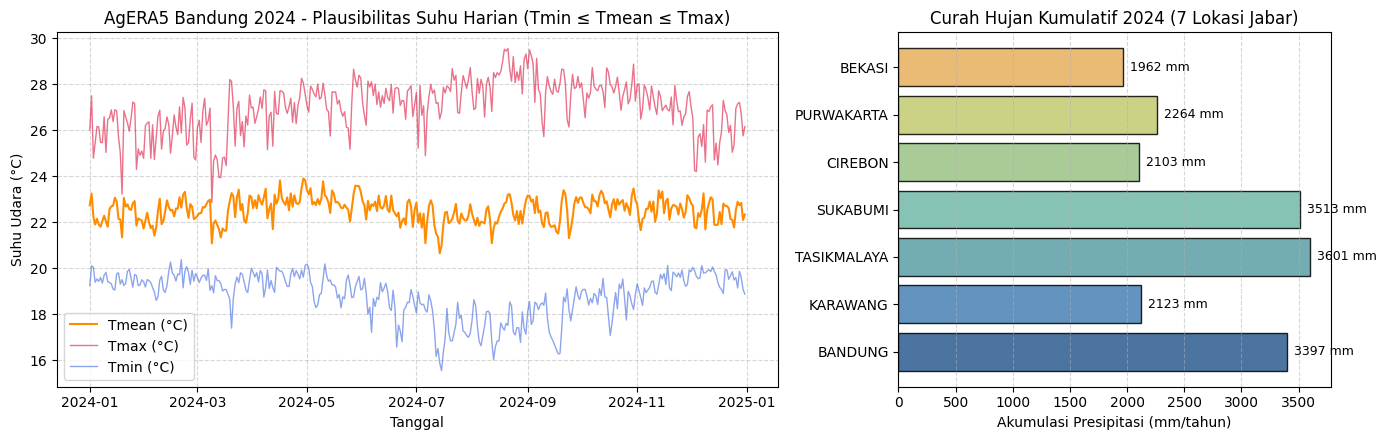

Gambar PNG berhasil disimpan ke: C:\CODING\research_taniAdapt\reports\figures\ds01_agera5_plausibility.png


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5), gridspec_kw={'width_ratios': [2, 1.2]})

# Panel 1: Suhu Bandung 2024
df_bandung['valid_time'] = pd.to_datetime(df_bandung['valid_time'])
df_2024 = df_bandung[df_bandung['valid_time'].dt.year == 2024]

ax1.plot(df_2024['valid_time'], df_2024['Temperature_Air_2m_Mean_24h'] - 273.15, label='Tmean (°C)', color='darkorange', linewidth=1.5)
ax1.plot(df_2024['valid_time'], df_2024['Temperature_Air_2m_Max_24h'] - 273.15, label='Tmax (°C)', color='crimson', alpha=0.6, linewidth=1)
ax1.plot(df_2024['valid_time'], df_2024['Temperature_Air_2m_Min_24h'] - 273.15, label='Tmin (°C)', color='royalblue', alpha=0.6, linewidth=1)
ax1.set_title("AgERA5 Bandung 2024 - Plausibilitas Suhu Harian (Tmin ≤ Tmean ≤ Tmax)")
ax1.set_xlabel("Tanggal")
ax1.set_ylabel("Suhu Udara (°C)")
ax1.legend(loc='lower left')
ax1.grid(True, linestyle='--', alpha=0.5)

# Panel 2: Komparasi Presipitasi Tahunan 2024 (7 Lokasi Jabar)
colors = ['#2b5c8f', '#4682b4', '#5c9ea6', '#72b9a8', '#99c286', '#c4cb70', '#e6af5d']
bars = ax2.barh(df_loc_summary['Lokasi'], df_loc_summary['Curah Hujan 2024 (mm)'], color=colors, edgecolor='black', alpha=0.85)
ax2.set_title("Curah Hujan Kumulatif 2024 (7 Lokasi Jabar)")
ax2.set_xlabel("Akumulasi Presipitasi (mm/tahun)")
ax2.grid(axis='x', linestyle='--', alpha=0.5)
for bar in bars:
    w = bar.get_width()
    ax2.annotate(f"{w:.0f} mm", xy=(w, bar.get_y() + bar.get_height()/2),
                 xytext=(5, 0), textcoords="offset points", ha='left', va='center', fontsize=9)

plt.tight_layout()
png_out = FIGURES_DIR / "ds01_agera5_plausibility.png"
plt.savefig(png_out, dpi=150)
plt.show()
print(f"Gambar PNG berhasil disimpan ke: {png_out}")


## Executive Audit Scorecard
Ringkasan metrik audit kualitas dataset AgERA5 untuk pengambilan keputusan di TaniAdapt.


In [6]:
scorecard = pd.DataFrame([
    {"Dimensi Audit": "Dataset Identifier", "Hasil & Evaluasi": "DS01 — AgERA5 Agrometeorological Indicators"},
    {"Dimensi Audit": "Penerbit & Sumber", "Hasil & Evaluasi": "ECMWF / Copernicus Climate Data Store (CDS OpenAPI)"},
    {"Dimensi Audit": "Cakupan Wilayah", "Hasil & Evaluasi": "7 Sentra Pertanian Jawa Barat (Bandung, Karawang, Tasikmalaya, Sukabumi, Cirebon, Purwakarta, Bekasi)"},
    {"Dimensi Audit": "Cakupan Temporal", "Hasil & Evaluasi": "10 Tahun Kalender Penuh (2015-01-01 s.d. 2024-12-31 = 3.653 Hari)"},
    {"Dimensi Audit": "Kelengkapan Nilai", "Hasil & Evaluasi": "100% Lengkap (0 Missing Values di seluruh 7 lokasi)"},
    {"Dimensi Audit": "Plausibilitas Fisis", "Hasil & Evaluasi": "PASSED (Memenuhi hukum batas suhu, presipitasi >= 0, RH 0-100%, VPD >= 0)"},
    {"Dimensi Audit": "Sampel Linking Riil", "Hasil & Evaluasi": "N_eff = 42 baris pada Padi (DS03) dan 56 baris pada Jagung (DS05)"},
    {"Dimensi Audit": "Peran di TaniAdapt", "Hasil & Evaluasi": "Primary Weather & Agroclimatic Backbone"},
    {"Dimensi Audit": "Status Disposisi", "Hasil & Evaluasi": "PASS (Layak sebagai tulang punggung iklim mikro)"},
    {"Dimensi Audit": "Batasan Kritis", "Hasil & Evaluasi": "Data reanalisis grid spasial 0,1° (~10 km); bukan sensor stasiun on-farm."}
])

display(scorecard)


,Dimensi Audit,Hasil & Evaluasi
0,Dataset Identifier,DS01 — AgERA5 Agrometeorological Indicators
1,Penerbit & Sumber,ECMWF / Copernicus Climate Data Store (CDS Ope...
2,Cakupan Wilayah,"7 Sentra Pertanian Jawa Barat (Bandung, Karawa..."
3,Cakupan Temporal,10 Tahun Kalender Penuh (2015-01-01 s.d. 2024-...
4,Kelengkapan Nilai,100% Lengkap (0 Missing Values di seluruh 7 lo...
5,Plausibilitas Fisis,"PASSED (Memenuhi hukum batas suhu, presipitasi..."
6,Sampel Linking Riil,N_eff = 42 baris pada Padi (DS03) dan 56 baris...
7,Peran di TaniAdapt,Primary Weather & Agroclimatic Backbone
8,Status Disposisi,PASS (Layak sebagai tulang punggung iklim mikro)
9,Batasan Kritis,"Data reanalisis grid spasial 0,1° (~10 km); bu..."
